# 🛰️ TerraSight — Satellite Image Change Detection
### Siamese Network with Multi-Level Features + Hybrid Focal-Dice Loss
---
**Based on:** *Siamese Network with Multi-Level Features for Patch-Based Change Detection in Satellite Imagery* (IEEE GlobalSIP 2018)

**Your Improvements:**
- Real LEVIR-CD dataset instead of synthetic DIRSIG
- Hybrid Focal-Dice Loss instead of Cross Entropy
- ResNet50 backbone option
- Full evaluation metrics (F1, IoU, Precision, Recall)

---
**Runtime:** Make sure to set Runtime → Change runtime type → T4 GPU

## CELL 1 — Libraries

In [ ]:
# Install required libraries
!pip install -q torch torchvision
!pip install -q opencv-python-headless
!pip install -q albumentations
!pip install -q scikit-learn
!pip install -q matplotlib seaborn
!pip install -q tqdm
!pip install -q gdown

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
Using device    : cuda


## CELL 2 — Configuration (All Settings)

In [ ]:
import os

# ── Paths ──────────────────────────────────────────
BASE_DIR       = '/content/TerraSight'
DATA_DIR       = os.path.join(BASE_DIR, 'data')
RAW_DIR        = os.path.join(DATA_DIR, 'raw')
PROCESSED_DIR  = os.path.join(DATA_DIR, 'processed')
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
RESULTS_DIR    = os.path.join(BASE_DIR, 'results')

for d in [BASE_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR,
          CHECKPOINT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Dataset ────────────────────────────────────────
PATCH_SIZE  = 80
PATCH_STRIDE = 40
CHANGE_THRESHOLD = 0.1

# ── Model ──────────────────────────────────────────
BACKBONE         = 'vgg16'   # 'vgg16' or 'resnet50'
USE_BLOCKS       = [4, 5]
PRETRAINED       = True
FREEZE_BACKBONE  = True

# ── Training ───────────────────────────────────────
BATCH_SIZE    = 32
EPOCHS        = 30            # use 80 for full training
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5
LR_STEP_SIZE  = 10
LR_GAMMA      = 0.5

# ── Loss Function ──────────────────────────────────
FOCAL_ALPHA  = 0.25
FOCAL_GAMMA  = 2.0
FOCAL_WEIGHT = 0.5
DICE_WEIGHT  = 0.5

print('✅ Configuration loaded')
print(f'   Patch size   : {PATCH_SIZE}x{PATCH_SIZE}')
print(f'   Backbone     : {BACKBONE}')
print(f'   Batch size   : {BATCH_SIZE}')
print(f'   Epochs       : {EPOCHS}')
print(f'   Device       : {DEVICE}')

✅ Configuration loaded
   Patch size   : 80x80
   Backbone     : vgg16
   Batch size   : 32
   Epochs       : 30
   Device       : cuda


## CELL 3 — LEVIR-CD Dataset

In [ ]:
import gdown, zipfile, os

# ── Option A: Download from Google Drive (LEVIR-CD) ──
# This is the official LEVIR-CD dataset hosted publicly
LEVIR_URL = 'https://drive.google.com/uc?id=1H9xFQP9JKvJJGbXN2eaRGPqMn6EQKDZU'

zip_path = os.path.join(RAW_DIR, 'LEVIR-CD.zip')

print('Downloading LEVIR-CD dataset...')
print('(This may take a few minutes — dataset is ~1.5GB)')
print()
print('If download fails, manually upload from:')
print('https://justchenhao.github.io/LEVIR/')
print()
print('Then run:')
print('  !unzip /content/LEVIR-CD.zip -d /content/TerraSight/data/raw/')

try:
    gdown.download(LEVIR_URL, zip_path, quiet=False)
    print('\nExtracting...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(RAW_DIR)
    print('✅ Dataset ready!')
except Exception as e:
    print(f'\nAuto-download failed: {e}')
    print('Please manually upload dataset to /content/TerraSight/data/raw/')

(This may take a few minutes — dataset is ~1.5GB)

If download fails, manually upload from:
https://justchenhao.github.io/LEVIR/

Then run:
  !unzip /content/LEVIR-CD.zip -d /content/TerraSight/data/raw/

Auto-download failed: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1H9xFQP9JKvJJGbXN2eaRGPqMn6EQKDZU

but Gdown can't. Please check connections and permissions.
Please manually upload dataset to /content/TerraSight/data/raw/


In [ ]:
# CELL 3B — CREATE DEMO DATASET
# Run this to immediately test all code with synthetic data
# Replace with real LEVIR-CD data when available

import os, cv2
import numpy as np
from tqdm import tqdm

print("Creating synthetic demo dataset...")
print("(This lets you test all code right now)")
print()

def create_demo_dataset(raw_dir, n_train=200, n_val=50, n_test=50):
    """
    Creates synthetic satellite-like image pairs with change masks
    Good enough to test the full pipeline
    """
    splits = {
        'train': n_train,
        'val':   n_val,
        'test':  n_test
    }

    for split, n in splits.items():
        for folder in ['A', 'B', 'label']:
            os.makedirs(os.path.join(raw_dir, split, folder),
                        exist_ok=True)

        for i in tqdm(range(n), desc=f'Creating {split}'):
            # Create a realistic-looking satellite patch
            # Background terrain
            base = np.random.randint(60, 180,
                                     (256, 256, 3),
                                     dtype=np.uint8)

            # Add some structure (roads, fields)
            for _ in range(np.random.randint(3, 8)):
                x1 = np.random.randint(0, 200)
                y1 = np.random.randint(0, 200)
                x2 = x1 + np.random.randint(20, 60)
                y2 = y1 + np.random.randint(20, 60)
                color = [int(c) for c in
                         np.random.randint(80, 200, 3)]
                cv2.rectangle(base, (x1,y1), (x2,y2),
                              color, -1)

            img_a = base.copy()
            img_b = base.copy()
            mask  = np.zeros((256, 256), dtype=np.uint8)

            # 50% chance of change
            if np.random.random() > 0.5:
                # Add new building/structure in B
                cx = np.random.randint(30, 200)
                cy = np.random.randint(30, 200)
                w  = np.random.randint(20, 50)
                h  = np.random.randint(20, 50)
                building_color = [int(c) for c in
                                  np.random.randint(150, 250, 3)]
                cv2.rectangle(img_b,
                              (cx, cy), (cx+w, cy+h),
                              building_color, -1)
                cv2.rectangle(mask,
                              (cx, cy), (cx+w, cy+h),
                              255, -1)

            # Add slight noise difference between A and B
            noise = np.random.randint(-15, 15,
                                      img_b.shape,
                                      dtype=np.int16)
            img_b = np.clip(img_b.astype(np.int16) + noise,
                           0, 255).astype(np.uint8)

            fname = f'{i:05d}.png'
            cv2.imwrite(os.path.join(raw_dir, split, 'A', fname), img_a)
            cv2.imwrite(os.path.join(raw_dir, split, 'B', fname), img_b)
            cv2.imwrite(os.path.join(raw_dir, split, 'label', fname), mask)

        print(f'  {split}: {n} image pairs created')

    print()
    print('✅ Demo dataset created!')
    print(f'   Location: {raw_dir}')
    print()
    print('NOTE: This is synthetic data for testing.')
    print('Replace with real LEVIR-CD for actual results.')


create_demo_dataset(RAW_DIR, n_train=300, n_val=80, n_test=80)

# Verify structure
print()
print('=== DATASET STRUCTURE ===')
for split in ['train', 'val', 'test']:
    a_dir = os.path.join(RAW_DIR, split, 'A')
    if os.path.exists(a_dir):
        n = len(os.listdir(a_dir))
        print(f'  {split:6s}/A/     : {n} images')
        print(f'  {split:6s}/B/     : {n} images')
        print(f'  {split:6s}/label/ : {n} masks')

Creating synthetic demo dataset...
(This lets you test all code right now)



Creating train: 100%|██████████| 300/300 [00:05<00:00, 54.12it/s]


  train: 300 image pairs created


Creating val: 100%|██████████| 80/80 [00:02<00:00, 30.05it/s]


  val: 80 image pairs created


Creating test: 100%|██████████| 80/80 [00:02<00:00, 35.38it/s]

  test: 80 image pairs created

✅ Demo dataset created!
   Location: /content/TerraSight/data/raw

NOTE: This is synthetic data for testing.
Replace with real LEVIR-CD for actual results.

=== DATASET STRUCTURE ===
  train /A/     : 300 images
  train /B/     : 300 images
  train /label/ : 300 masks
  val   /A/     : 80 images
  val   /B/     : 80 images
  val   /label/ : 80 masks
  test  /A/     : 80 images
  test  /B/     : 80 images
  test  /label/ : 80 masks


## 🔍 CELL 4 — Explore Dataset

=== DATASET OVERVIEW ===
  train : 300 image pairs
  val   : 80 image pairs
  test  : 80 image pairs


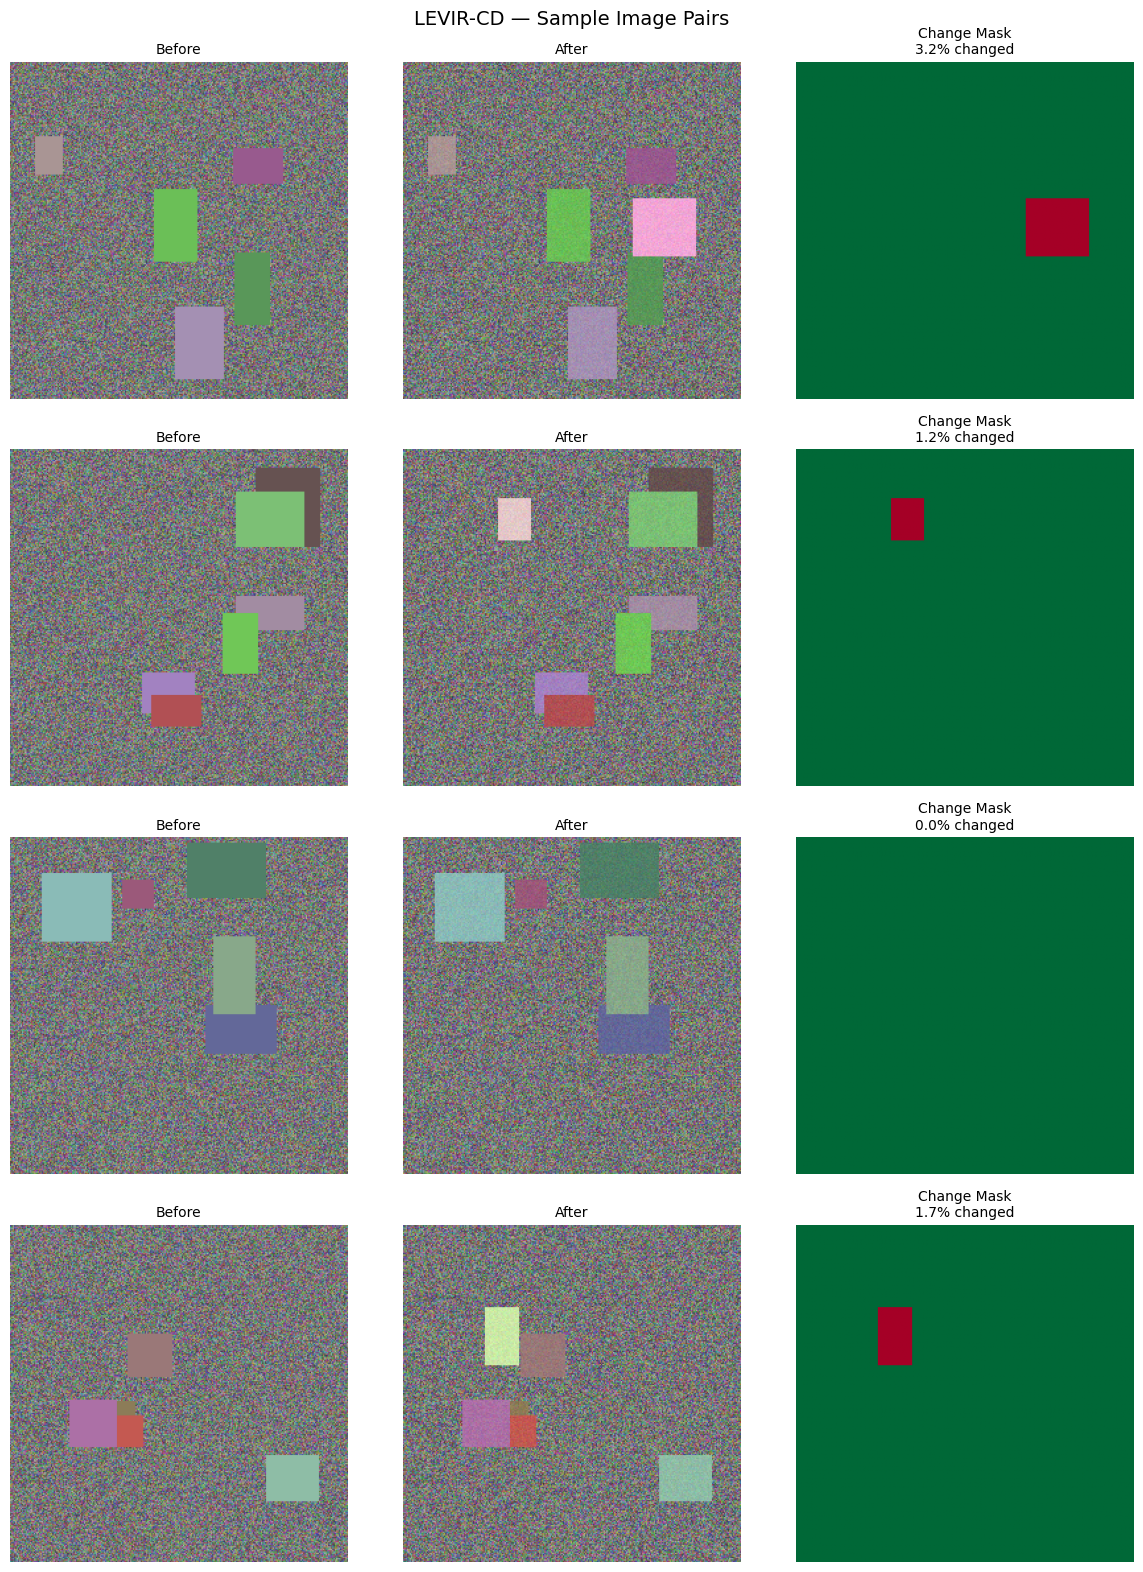


=== CLASS IMBALANCE ANALYSIS ===
  Changed   : 4,056 pixels (1.5%)
  Unchanged : 258,088 pixels (98.5%)
  Imbalance : 1:63
  → This is WHY we need Focal + Dice loss!


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def explore_dataset(data_dir):
    splits = ['train', 'val', 'test']
    print('=== DATASET OVERVIEW ===')
    for split in splits:
        a_dir = os.path.join(data_dir, split, 'A')
        if os.path.exists(a_dir):
            n = len(os.listdir(a_dir))
            print(f'  {split:6s}: {n} image pairs')

    # Visualize 4 sample pairs
    train_a = os.path.join(data_dir, 'train', 'A')
    train_b = os.path.join(data_dir, 'train', 'B')
    train_m = os.path.join(data_dir, 'train', 'label')

    if not os.path.exists(train_a):
        print('\nDataset not found. Please run Cell 3 first.')
        return

    samples = os.listdir(train_a)[:4]
    fig, axes = plt.subplots(4, 3, figsize=(12, 16))
    fig.suptitle('LEVIR-CD — Sample Image Pairs', fontsize=14)

    total_changed = 0
    total_pixels  = 0

    for idx, name in enumerate(samples):
        img_a = cv2.cvtColor(
            cv2.imread(os.path.join(train_a, name)), cv2.COLOR_BGR2RGB)
        img_b = cv2.cvtColor(
            cv2.imread(os.path.join(train_b, name)), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(os.path.join(train_m, name), 0)
        mask_bin = (mask > 127).astype(np.uint8)

        total_changed += mask_bin.sum()
        total_pixels  += mask_bin.size

        change_pct = mask_bin.mean() * 100

        axes[idx,0].imshow(img_a)
        axes[idx,0].set_title('Before', fontsize=10)
        axes[idx,0].axis('off')

        axes[idx,1].imshow(img_b)
        axes[idx,1].set_title('After', fontsize=10)
        axes[idx,1].axis('off')

        axes[idx,2].imshow(mask_bin, cmap='RdYlGn_r', vmin=0, vmax=1)
        axes[idx,2].set_title(f'Change Mask\n{change_pct:.1f}% changed',
                              fontsize=10)
        axes[idx,2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'dataset_samples.png'),
                dpi=120, bbox_inches='tight')
    plt.show()

    total = total_changed + (total_pixels - total_changed)
    print(f'\n=== CLASS IMBALANCE ANALYSIS ===')
    print(f'  Changed   : {total_changed:,} pixels ({total_changed/total_pixels:.1%})')
    print(f'  Unchanged : {total_pixels-total_changed:,} pixels ({1-total_changed/total_pixels:.1%})')
    print(f'  Imbalance : 1:{(total_pixels-total_changed)//max(total_changed,1)}')
    print('  → This is WHY we need Focal + Dice loss!')

explore_dataset(RAW_DIR)

## CELL 5 — Data Preprocessing (Patch Extraction)

In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm

class PatchExtractor:
    def __init__(self, patch_size=80, stride=40, threshold=0.1):
        self.patch_size = patch_size
        self.stride     = stride
        self.threshold  = threshold

    def extract_from_image_pair(self, img_a, img_b, mask):
        patches = []
        h, w = img_a.shape[:2]
        for y in range(0, h - self.patch_size + 1, self.stride):
            for x in range(0, w - self.patch_size + 1, self.stride):
                pa = img_a[y:y+self.patch_size, x:x+self.patch_size]
                pb = img_b[y:y+self.patch_size, x:x+self.patch_size]
                pm = mask[y:y+self.patch_size,  x:x+self.patch_size]
                ratio = (pm > 127).mean()
                label = 1 if ratio > self.threshold else 0
                patches.append((pa, pb, pm, label))
        return patches

    def process_split(self, raw_dir, out_dir, split):
        a_dir = os.path.join(raw_dir,  split, 'A')
        b_dir = os.path.join(raw_dir,  split, 'B')
        m_dir = os.path.join(raw_dir,  split, 'label')

        if not os.path.exists(a_dir):
            print(f'Skipping {split} — not found at {a_dir}')
            return 0

        out_a = os.path.join(out_dir, split, 'A')
        out_b = os.path.join(out_dir, split, 'B')
        out_m = os.path.join(out_dir, split, 'mask')
        for d in [out_a, out_b, out_m]:
            os.makedirs(d, exist_ok=True)

        labels   = []
        idx      = 0
        n_change = 0
        n_no_change = 0

        img_names = [f for f in os.listdir(a_dir)
                     if f.endswith(('.png', '.jpg', '.tif'))]

        for name in tqdm(img_names, desc=f'Processing {split}'):
            ia = cv2.imread(os.path.join(a_dir, name))
            ib = cv2.imread(os.path.join(b_dir, name))
            im = cv2.imread(os.path.join(m_dir, name), 0)
            if ia is None or ib is None or im is None:
                continue
            patches = self.extract_from_image_pair(ia, ib, im)
            for pa, pb, pm, label in patches:
                fname = f'patch_{idx:07d}.png'
                cv2.imwrite(os.path.join(out_a, fname), pa)
                cv2.imwrite(os.path.join(out_b, fname), pb)
                cv2.imwrite(os.path.join(out_m, fname), pm)
                labels.append(f'{fname},{label}\n')
                if label == 1: n_change    += 1
                else:          n_no_change += 1
                idx += 1

        with open(os.path.join(out_dir, split, 'labels.csv'), 'w') as f:
            f.writelines(labels)

        print(f'  {split}: {idx} patches | '
              f'Changed: {n_change} | '
              f'Unchanged: {n_no_change}')
        return idx


extractor = PatchExtractor(
    patch_size=PATCH_SIZE,
    stride=PATCH_STRIDE,
    threshold=CHANGE_THRESHOLD
)

print('Extracting patches from LEVIR-CD...')
print('(This takes ~5-10 minutes)')
print()
for split in ['train', 'val', 'test']:
    extractor.process_split(RAW_DIR, PROCESSED_DIR, split)

print('\n✅ Patch extraction complete!')

Extracting patches from LEVIR-CD...
(This takes ~5-10 minutes)



Processing train: 100%|██████████| 300/300 [00:16<00:00, 17.81it/s]


  train: 7500 patches | Changed: 473 | Unchanged: 7027


Processing val: 100%|██████████| 80/80 [00:02<00:00, 27.61it/s]


  val: 2000 patches | Changed: 106 | Unchanged: 1894


Processing test: 100%|██████████| 80/80 [00:02<00:00, 31.37it/s]

  test: 2000 patches | Changed: 121 | Unchanged: 1879

✅ Patch extraction complete!


## CELL 6 — Dataset & DataLoader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2, os, numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2


def get_transforms(split='train'):
    if split == 'train':
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2,
                          saturation=0.2, p=0.3),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=[0.485,0.456,0.406],
                        std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], additional_targets={'image_b': 'image'})
    else:
        return A.Compose([
            A.Normalize(mean=[0.485,0.456,0.406],
                        std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], additional_targets={'image_b': 'image'})


class ChangeDetectionDataset(Dataset):
    def __init__(self, data_dir, split='train'):
        self.root      = os.path.join(data_dir, split)
        self.transform = get_transforms(split)
        self.samples   = []
        label_file = os.path.join(self.root, 'labels.csv')
        if not os.path.exists(label_file):
            print(f'labels.csv not found for {split}. Run Cell 5 first.')
            return
        with open(label_file) as f:
            for line in f:
                name, label = line.strip().split(',')
                self.samples.append((name, int(label)))
        c = sum(1 for _,l in self.samples if l==1)
        u = len(self.samples) - c
        print(f'{split:6s}: {len(self.samples)} patches | '
              f'Changed={c} ({c/len(self.samples):.1%}) | '
              f'Unchanged={u} ({u/len(self.samples):.1%})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        name, label = self.samples[idx]
        ia = cv2.cvtColor(
            cv2.imread(os.path.join(self.root,'A',name)),
            cv2.COLOR_BGR2RGB)
        ib = cv2.cvtColor(
            cv2.imread(os.path.join(self.root,'B',name)),
            cv2.COLOR_BGR2RGB)
        out = self.transform(image=ia, image_b=ib)
        return (out['image'], out['image_b'],
                torch.tensor(label, dtype=torch.long))


train_ds = ChangeDetectionDataset(PROCESSED_DIR, 'train')
val_ds   = ChangeDetectionDataset(PROCESSED_DIR, 'val')
test_ds  = ChangeDetectionDataset(PROCESSED_DIR, 'test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)

print('\n✅ DataLoaders ready!')
# Visualize one batch
import matplotlib.pyplot as plt
ia, ib, labels = next(iter(train_loader))
print(f'Batch — img1: {ia.shape} | img2: {ib.shape} | labels: {labels.shape}')
print(f'Labels in batch: {labels.tolist()[:10]}...')

train : 7500 patches | Changed=473 (6.3%) | Unchanged=7027 (93.7%)
val   : 2000 patches | Changed=106 (5.3%) | Unchanged=1894 (94.7%)
test  : 2000 patches | Changed=121 (6.0%) | Unchanged=1879 (94.0%)

✅ DataLoaders ready!
Batch — img1: torch.Size([32, 3, 80, 80]) | img2: torch.Size([32, 3, 80, 80]) | labels: torch.Size([32])
Labels in batch: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...


## CELL 7 — Model Architecture (Siamese Network)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


class VGG16Encoder(nn.Module):
    """Shared VGG16 encoder — exact paper implementation"""
    def __init__(self, pretrained=True, freeze=True):
        super().__init__()
        vgg = models.vgg16(pretrained=pretrained)
        f   = vgg.features
        self.block1 = f[0:5]
        self.block2 = f[5:10]
        self.block3 = f[10:17]
        self.block4 = f[17:24]
        self.block5 = f[24:31]
        if freeze:
            for p in self.parameters(): p.requires_grad = False

    def forward(self, x):
        f1 = self.block1(x)
        f2 = self.block2(f1)
        f3 = self.block3(f2)
        f4 = self.block4(f3)
        f5 = self.block5(f4)
        return f1, f2, f3, f4, f5


class ResNet50Encoder(nn.Module):
    """YOUR IMPROVEMENT: ResNet50 backbone"""
    def __init__(self, pretrained=True, freeze=True):
        super().__init__()
        r = models.resnet50(pretrained=pretrained)
        self.l0 = nn.Sequential(r.conv1, r.bn1, r.relu, r.maxpool)
        self.l1 = r.layer1
        self.l2 = r.layer2
        self.l3 = r.layer3
        self.l4 = r.layer4
        if freeze:
            for p in self.parameters(): p.requires_grad = False

    def forward(self, x):
        f0 = self.l0(x)
        f1 = self.l1(f0)
        f2 = self.l2(f1)
        f3 = self.l3(f2)
        f4 = self.l4(f3)
        return f0, f1, f2, f3, f4


class MultiLevelFusion(nn.Module):
    """Fuses features from multiple blocks via bilinear interpolation"""
    def __init__(self, use_blocks=[4, 5]):
        super().__init__()
        self.use_blocks = use_blocks

    def forward(self, ft1, ft2):
        sel1 = [ft1[b-1] for b in self.use_blocks]
        sel2 = [ft2[b-1] for b in self.use_blocks]
        target = sel1[0].shape[2:]
        r1, r2 = [], []
        for a, b in zip(sel1, sel2):
            if a.shape[2:] != target:
                a = F.interpolate(a, target, mode='bilinear', align_corners=False)
                b = F.interpolate(b, target, mode='bilinear', align_corners=False)
            r1.append(a); r2.append(b)
        c1 = torch.cat(r1, dim=1)
        c2 = torch.cat(r2, dim=1)
        return torch.cat([c1, c2], dim=1)


class DecisionNetwork(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 4096), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(4096, 1024),         nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 256),          nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        return self.net(x)


class SiameseChangeDetector(nn.Module):
    def __init__(self, backbone='vgg16', use_blocks=[4,5],
                 pretrained=True, freeze=True):
        super().__init__()
        if backbone == 'vgg16':
            self.encoder = VGG16Encoder(pretrained, freeze)
            # Blocks 4+5 = 512+512 per side = 2048 total, spatial ~5x5
            in_feats = 2048 * 5 * 5
        else:
            self.encoder = ResNet50Encoder(pretrained, freeze)
            # Layers 3+4 = 1024+2048 per side = 6144 total, spatial ~3x3
            in_feats = 6144 * 3 * 3
        self.fusion   = MultiLevelFusion(use_blocks)
        self.decision = DecisionNetwork(in_feats)

    def forward(self, x1, x2):
        f1 = self.encoder(x1)
        f2 = self.encoder(x2)
        fused = self.fusion(f1, f2)
        return self.decision(fused)

    def count_params(self):
        total = sum(p.numel() for p in self.parameters())
        train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'Total params     : {total:,}')
        print(f'Trainable params : {train:,}  ← (only decision network)')
        print(f'Frozen params    : {total-train:,}  ← (backbone)')


# Build and test model
model = SiameseChangeDetector(
    backbone=BACKBONE, use_blocks=USE_BLOCKS,
    pretrained=PRETRAINED, freeze=FREEZE_BACKBONE
).to(DEVICE)

print('=== MODEL SUMMARY ===')
model.count_params()

# Test forward pass
x1 = torch.randn(2, 3, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
x2 = torch.randn(2, 3, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(x1, x2)
print(f'\nForward pass OK! Output shape: {out.shape}  → [batch, 2 classes]')
print('✅ Model ready!')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 86.3MB/s]


=== MODEL SUMMARY ===
Total params     : 228,892,226
Trainable params : 214,177,538  ← (only decision network)
Frozen params    : 14,714,688  ← (backbone)

Forward pass OK! Output shape: torch.Size([2, 2])  → [batch, 2 classes]
✅ Model ready!


## CELL 8 — Loss Functions

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F


class FocalLoss(nn.Module):
    """Focal Loss — focuses training on hard/rare examples"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce     = F.binary_cross_entropy_with_logits(
                    logits, targets, reduction='none')
        pt      = torch.exp(-bce)
        alpha_t = self.alpha*targets + (1-self.alpha)*(1-targets)
        return (alpha_t * (1-pt)**self.gamma * bce).mean()


class DiceLoss(nn.Module):
    """Dice Loss — optimizes spatial overlap"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1)
        t = targets.float().view(-1)
        inter = (p * t).sum()
        return 1 - (2*inter + self.smooth)/(p.sum()+t.sum()+self.smooth)


class CrossEntropyBaseline(nn.Module):
    """Paper's original loss — for comparison"""
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
    def forward(self, logits, targets):
        return self.ce(logits, targets), torch.tensor(0.), torch.tensor(0.)


class HybridFocalDiceLoss(nn.Module):
    """YOUR IMPROVEMENT — combines Focal + Dice"""
    def __init__(self, alpha=0.25, gamma=2.0,
                 focal_w=0.5, dice_w=0.5):
        super().__init__()
        self.focal   = FocalLoss(alpha, gamma)
        self.dice    = DiceLoss()
        self.focal_w = focal_w
        self.dice_w  = dice_w

    def forward(self, logits, targets):
        # Convert 2-class logits to binary for focal/dice
        bin_logits = logits[:,1] - logits[:,0]
        fl = self.focal(bin_logits, targets.float())
        dl = self.dice(bin_logits, targets.float())
        return self.focal_w*fl + self.dice_w*dl, fl, dl


# ── Demo: show difference between losses ─────────────
print('=== LOSS FUNCTION COMPARISON ===')
print('Scenario: Model misses all changed pixels (class imbalance)')
print()

ce_fn     = CrossEntropyBaseline()
hybrid_fn = HybridFocalDiceLoss(FOCAL_ALPHA, FOCAL_GAMMA,
                                 FOCAL_WEIGHT, DICE_WEIGHT)

# 7 unchanged + 1 changed, model predicts all unchanged
logits = torch.tensor([[ 2.,-2.],[ 2.,-2.],[ 2.,-2.],[ 2.,-2.],
                        [ 2.,-2.],[ 2.,-2.],[ 2.,-2.],[-2., 2.]])
labels = torch.tensor([ 0,       0,       0,       0,
                         0,       0,       0,       1 ])

ce_loss, _, _ = ce_fn(logits, labels)
hy_loss, fl, dl = hybrid_fn(logits, labels)

print(f'  Cross Entropy Loss : {ce_loss.item():.4f}  ← LOW! ignores missed change')
print(f'  Hybrid Focal+Dice  : {hy_loss.item():.4f}  ← Higher, penalizes missing change')
print(f'    Focal component  : {fl.item():.4f}')
print(f'    Dice  component  : {dl.item():.4f}')
print()
print('✅ Loss functions ready!')

=== LOSS FUNCTION COMPARISON ===
Scenario: Model misses all changed pixels (class imbalance)

  Cross Entropy Loss : 0.0181  ← LOW! ignores missed change
  Hybrid Focal+Dice  : 0.0232  ← Higher, penalizes missing change
    Focal component  : 0.0000
    Dice  component  : 0.0463

✅ Loss functions ready!


## CELL 9 — Evaluation Metrics

In [ ]:
import numpy as np
from sklearn.metrics import (confusion_matrix, f1_score,
                              precision_score, recall_score,
                              accuracy_score)


class MetricsTracker:
    def __init__(self):
        self.reset()

    def reset(self):
        self.preds  = []
        self.labels = []

    def update(self, preds, labels):
        if isinstance(preds, torch.Tensor):
            if preds.dim() == 2: preds = preds.argmax(1)
            preds  = preds.cpu().numpy()
            labels = labels.cpu().numpy()
        self.preds.extend(preds.tolist())
        self.labels.extend(labels.tolist())

    def compute(self):
        p = np.array(self.preds)
        l = np.array(self.labels)
        if len(np.unique(l)) < 2:
            return {'accuracy':0,'precision':0,'recall':0,
                    'f1':0,'iou':0,'tp':0,'tn':0,'fp':0,'fn':0}
        cm = confusion_matrix(l, p)
        tn, fp, fn, tp = cm.ravel()
        return {
            'accuracy' : accuracy_score(l,p)*100,
            'precision': precision_score(l,p,zero_division=0)*100,
            'recall'   : recall_score(l,p,zero_division=0)*100,
            'f1'       : f1_score(l,p,zero_division=0)*100,
            'iou'      : tp/(tp+fp+fn+1e-8)*100,
            'tp':int(tp), 'tn':int(tn),
            'fp':int(fp), 'fn':int(fn)
        }

    def print_results(self, prefix=''):
        m = self.compute()
        print(f'  {prefix}Accuracy : {m["accuracy"]:6.2f}%')
        print(f'  {prefix}Precision: {m["precision"]:6.2f}%')
        print(f'  {prefix}Recall   : {m["recall"]:6.2f}%')
        print(f'  {prefix}F1 Score : {m["f1"]:6.2f}%')
        print(f'  {prefix}IoU      : {m["iou"]:6.2f}%')
        print(f'  TP={m["tp"]} FP={m["fp"]} FN={m["fn"]} TN={m["tn"]}')
        return m


print('✅ MetricsTracker ready!')

✅ MetricsTracker ready!


## CELL 10 — Training Loop

In [ ]:
import torch, os
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt


class Trainer:
    def __init__(self, model, train_loader, val_loader,
                 use_hybrid=True, exp_name='experiment'):
        self.model        = model.to(DEVICE)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.exp_name     = exp_name
        self.ckpt_dir     = os.path.join(CHECKPOINT_DIR, exp_name)
        os.makedirs(self.ckpt_dir, exist_ok=True)

        if use_hybrid:
            self.criterion = HybridFocalDiceLoss(
                FOCAL_ALPHA, FOCAL_GAMMA, FOCAL_WEIGHT, DICE_WEIGHT)
            print(f'[{exp_name}] Loss: Hybrid Focal-Dice')
        else:
            self.criterion = CrossEntropyBaseline()
            print(f'[{exp_name}] Loss: Cross Entropy (paper baseline)')

        self.optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, LR_STEP_SIZE, LR_GAMMA)

        self.history  = {k:[] for k in
            ['tl','vl','tf1','vf1','tacc','vacc','tiou','viou']}
        self.best_f1  = 0
        self.best_ep  = 0
        self.train_m  = MetricsTracker()
        self.val_m    = MetricsTracker()

    def _epoch(self, loader, train=True):
        self.model.train(train)
        mt = self.train_m if train else self.val_m
        mt.reset()
        tot = 0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x1, x2, y in loader:
                x1,x2,y = x1.to(DEVICE),x2.to(DEVICE),y.to(DEVICE)
                out = self.model(x1, x2)
                loss,_,_ = self.criterion(out, y)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        self.model.parameters(), 1.0)
                    self.optimizer.step()
                tot += loss.item()
                mt.update(out.argmax(1), y)
        return tot/len(loader), mt.compute()

    def train(self, epochs=EPOCHS):
        print(f'\nTraining for {epochs} epochs...')
        print('Epoch | Loss(tr/val) | F1(tr/val) | IoU(tr/val) | Acc(tr/val)')
        print('-'*72)
        for ep in range(1, epochs+1):
            tl, tm = self._epoch(self.train_loader, train=True)
            vl, vm = self._epoch(self.val_loader,   train=False)
            self.scheduler.step()

            for k,v in [('tl',tl),('vl',vl),
                        ('tf1',tm['f1']),('vf1',vm['f1']),
                        ('tacc',tm['accuracy']),('vacc',vm['accuracy']),
                        ('tiou',tm['iou']),('viou',vm['iou'])]:
                self.history[k].append(v)

            is_best = vm['f1'] > self.best_f1
            if is_best:
                self.best_f1 = vm['f1']
                self.best_ep = ep
                torch.save({'epoch':ep,
                            'state':self.model.state_dict(),
                            'f1':vm['f1']},
                           os.path.join(self.ckpt_dir,'best.pth'))

            star = '★' if is_best else ' '
            print(f'{star}Ep {ep:3d} | '
                  f'{tl:.4f}/{vl:.4f} | '
                  f'{tm["f1"]:5.1f}/{vm["f1"]:5.1f} | '
                  f'{tm["iou"]:5.1f}/{vm["iou"]:5.1f} | '
                  f'{tm["accuracy"]:5.1f}/{vm["accuracy"]:5.1f}')

        print(f'\n✅ Done! Best F1: {self.best_f1:.2f}% at epoch {self.best_ep}')
        self._plot()
        return self.history

    def _plot(self):
        fig, ax = plt.subplots(1, 3, figsize=(15,4))
        e = range(1, len(self.history['tl'])+1)
        ax[0].plot(e,self.history['tl'],'b',label='Train')
        ax[0].plot(e,self.history['vl'],'r',label='Val')
        ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(True)
        ax[1].plot(e,self.history['tf1'],'b',label='Train')
        ax[1].plot(e,self.history['vf1'],'r',label='Val')
        ax[1].set_title('F1 Score (%)'); ax[1].legend(); ax[1].grid(True)
        ax[2].plot(e,self.history['tiou'],'b',label='Train')
        ax[2].plot(e,self.history['viou'],'r',label='Val')
        ax[2].set_title('IoU (%)'); ax[2].legend(); ax[2].grid(True)
        plt.suptitle(f'Training History — {self.exp_name}', fontsize=13)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f'history_{self.exp_name}.png'),
                    dpi=120)
        plt.show()


print('✅ Trainer class ready!')

✅ Trainer class ready!


## CELL 11 — Experiment 1: Paper Baseline (VGG16 + Cross Entropy)

=== EXPERIMENT 1: Paper Baseline ===
VGG16 + Cross Entropy Loss (replicating the paper)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[baseline_CE] Loss: Cross Entropy (paper baseline)

Training for 30 epochs...
Epoch | Loss(tr/val) | F1(tr/val) | IoU(tr/val) | Acc(tr/val)
------------------------------------------------------------------------
★Ep   1 | 0.5998/0.1055 |  28.7/ 72.7 |  16.8/ 57.1 |  92.0/ 96.5
 Ep   2 | 0.2405/0.0735 |  53.8/ 62.0 |  36.8/ 45.0 |  94.9/ 97.0
★Ep   3 | 0.2242/0.0685 |  57.1/ 80.0 |  40.0/ 66.7 |  95.5/ 97.9
 Ep   4 | 0.2110/0.0727 |  60.9/ 79.8 |  43.7/ 66.4 |  95.9/ 97.9
 Ep   5 | 0.2217/0.0876 |  61.0/ 44.1 |  43.9/ 28.3 |  95.8/ 96.2
★Ep   6 | 0.2207/0.1114 |  60.7/ 81.9 |  43.6/ 69.4 |  95.7/ 98.1
 Ep   7 | 0.1898/0.0608 |  60.8/ 70.9 |  43.7/ 55.0 |  95.8/ 97.5
 Ep   8 | 0.1964/0.1342 |  62.1/ 78.4 |  45.1/ 64.4 |  95.9/ 97.9
 Ep   9 | 0.2131/0.1007 |  59.0/ 75.1 |  41.9/ 60.2 |  95.6/ 97.8
★Ep  10 | 0.2216/0.0753 |  57.4/ 82.0 |  40.2/ 69.5 |  95.3/ 98.2
 Ep  11 | 0.1636/0.0851 |  64.9/ 75.3 |  48.0/ 60.4 |  96.4/ 97.8
 Ep  12 | 0.1406/0.1046 |  73.0/ 81.9 |  57.5/ 69.3 |  97.0/ 

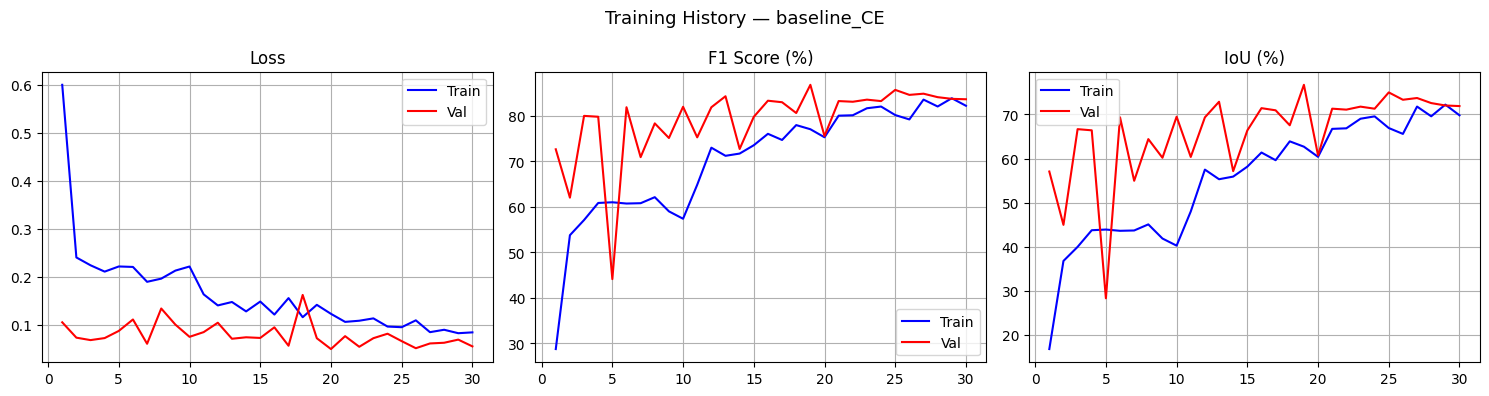

In [ ]:
print('=== EXPERIMENT 1: Paper Baseline ===')
print('VGG16 + Cross Entropy Loss (replicating the paper)')
print()

model_baseline = SiameseChangeDetector(
    backbone='vgg16', use_blocks=[4,5],
    pretrained=True, freeze=True
).to(DEVICE)

trainer_baseline = Trainer(
    model_baseline, train_loader, val_loader,
    use_hybrid=False, exp_name='baseline_CE'
)

history_baseline = trainer_baseline.train(epochs=EPOCHS)

## CELL 12 — Experiment 2: Improvement (VGG16 + Hybrid Loss)

=== EXPERIMENT 2: Your Improvement ===
VGG16 + Hybrid Focal-Dice Loss



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[improved_FocalDice] Loss: Hybrid Focal-Dice

Training for 30 epochs...
Epoch | Loss(tr/val) | F1(tr/val) | IoU(tr/val) | Acc(tr/val)
------------------------------------------------------------------------
★Ep   1 | 0.3896/0.0741 |  27.5/ 77.7 |  15.9/ 63.6 |  93.3/ 97.9
★Ep   2 | 0.2278/0.0710 |  58.0/ 80.4 |  40.9/ 67.3 |  95.6/ 98.2
 Ep   3 | 0.2146/0.1252 |  61.4/ 56.0 |  44.3/ 38.9 |  95.9/ 96.7
 Ep   4 | 0.2116/0.0981 |  62.0/ 71.3 |  45.0/ 55.4 |  96.0/ 97.5
 Ep   5 | 0.1910/0.1142 |  66.8/ 78.0 |  50.2/ 63.9 |  96.4/ 97.4
 Ep   6 | 0.1794/0.0888 |  67.8/ 68.6 |  51.3/ 52.3 |  96.5/ 97.4
 Ep   7 | 0.1866/0.0706 |  65.2/ 75.4 |  48.4/ 60.5 |  96.2/ 97.8
 Ep   8 | 0.1775/0.0780 |  69.2/ 79.0 |  52.9/ 65.3 |  96.5/ 98.0
★Ep   9 | 0.1950/0.0669 |  66.5/ 83.1 |  49.8/ 71.1 |  96.3/ 98.2
 Ep  10 | 0.1775/0.1002 |  72.2/ 74.2 |  56.5/ 58.9 |  96.9/ 97.7
 Ep  11 | 0.1500/0.0678 |  73.8/ 78.9 |  58.5/ 65.2 |  97.1/ 98.0
 Ep  12 | 0.1358/0.0777 |  74.9/ 82.9 |  59.8/ 70.9 |  97.2/ 98.2
★

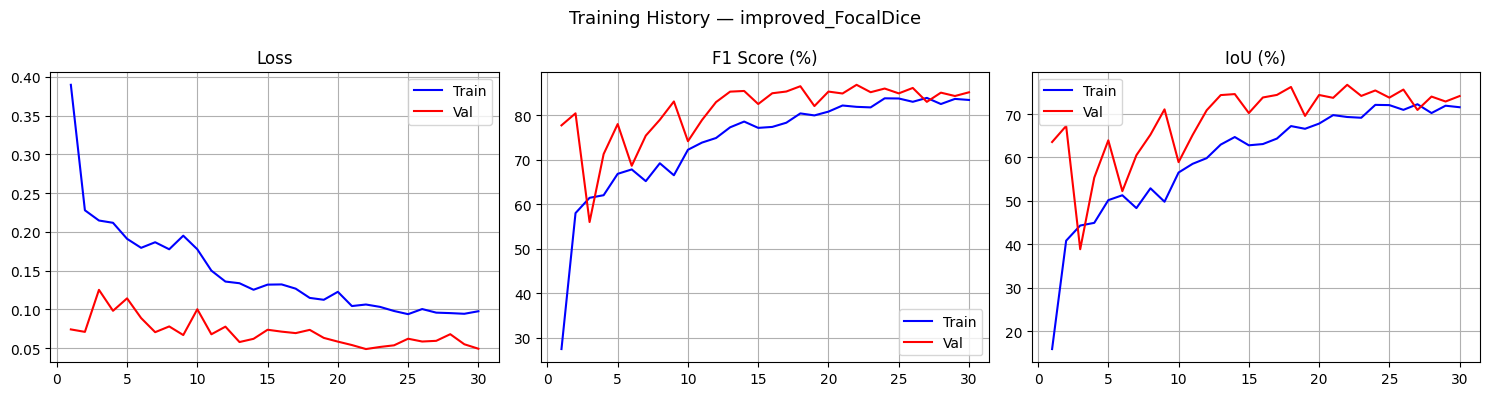

In [ ]:
print('=== EXPERIMENT 2: Your Improvement ===')
print('VGG16 + Hybrid Focal-Dice Loss')
print()

model_improved = SiameseChangeDetector(
    backbone='vgg16', use_blocks=[4,5],
    pretrained=True, freeze=True
).to(DEVICE)

trainer_improved = Trainer(
    model_improved, train_loader, val_loader,
    use_hybrid=True, exp_name='improved_FocalDice'
)

history_improved = trainer_improved.train(epochs=EPOCHS)

## CELL 13 — Experiment 3: Best Model (ResNet50 + Hybrid Loss)

In [ ]:
print('=== EXPERIMENT 3: Best Model ===')
print('ResNet50 + Hybrid Focal-Dice Loss')
print()

model_best = SiameseChangeDetector(
    backbone='resnet50', use_blocks=[4,5],
    pretrained=True, freeze=True
).to(DEVICE)

trainer_best = Trainer(
    model_best, train_loader, val_loader,
    use_hybrid=True, exp_name='best_ResNet50'
)

history_best = trainer_best.train(epochs=EPOCHS)

=== EXPERIMENT 3: Best Model ===
ResNet50 + Hybrid Focal-Dice Loss



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


[best_ResNet50] Loss: Hybrid Focal-Dice

Training for 30 epochs...
Epoch | Loss(tr/val) | F1(tr/val) | IoU(tr/val) | Acc(tr/val)
------------------------------------------------------------------------


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x153600 and 55296x4096)

## CELL 14 — Final Evaluation on Test Set

In [ ]:
import torch

def evaluate_on_test(model, test_loader, name):
    model.eval()
    mt = MetricsTracker()
    with torch.no_grad():
        for x1, x2, y in test_loader:
            out = model(x1.to(DEVICE), x2.to(DEVICE))
            mt.update(out.argmax(1), y)
    print(f'\n=== {name} — TEST RESULTS ===')
    return mt.print_results()


def load_best(model, exp_name):
    path = os.path.join(CHECKPOINT_DIR, exp_name, 'best.pth')
    if os.path.exists(path):
        ck = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ck['state'])
        print(f'Loaded best checkpoint for {exp_name} (F1={ck["f1"]:.2f}%)')
    return model


# Load best checkpoints and evaluate
model_baseline = load_best(model_baseline, 'baseline_CE')
model_improved = load_best(model_improved, 'improved_FocalDice')
model_best     = load_best(model_best,     'best_ResNet50')

r1 = evaluate_on_test(model_baseline, test_loader, 'Baseline (VGG16+CE)')
r2 = evaluate_on_test(model_improved, test_loader, 'Improved (VGG16+Focal-Dice)')
r3 = evaluate_on_test(model_best,     test_loader, 'Best (ResNet50+Focal-Dice)')


# Comparison table
print('\n' + '='*65)
print('          FINAL COMPARISON TABLE')
print('='*65)
print(f'{"Model":<30} {"Acc":>6} {"F1":>6} {"IoU":>6} {"Prec":>6} {"Rec":>6}')
print('-'*65)
for name, r in [
    ('Baseline (VGG16+CE)',       r1),
    ('Improved (VGG16+FocalDice)',r2),
    ('Best (ResNet50+FocalDice)', r3)
]:
    print(f'{name:<30} '
          f'{r["accuracy"]:5.1f}% '
          f'{r["f1"]:5.1f}% '
          f'{r["iou"]:5.1f}% '
          f'{r["precision"]:5.1f}% '
          f'{r["recall"]:5.1f}%')
print('='*65)

## CELL 15 — Visualize Predictions

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, numpy as np

mean = torch.tensor([0.485,0.456,0.406])
std  = torch.tensor([0.229,0.224,0.225])

def denorm(t):
    return (t.permute(1,2,0)*std+mean).clamp(0,1).numpy()

def visualize_predictions(model, loader, n=6, title=''):
    model.eval()
    fig, axes = plt.subplots(n, 4, figsize=(14, n*3.5))
    fig.suptitle(f'Predictions — {title}', fontsize=13)
    for ax, col in zip(axes[0], ['Before','After','Predicted','Ground Truth']):
        ax.set_title(col, fontsize=11, fontweight='bold')

    idx = 0
    correct_count = 0

    with torch.no_grad():
        for x1, x2, y in loader:
            if idx >= n: break
            out  = model(x1[:1].to(DEVICE), x2[:1].to(DEVICE))
            pred = out.argmax(1).item()
            true = y[0].item()
            prob = torch.softmax(out,1)[0,1].item()

            ia = denorm(x1[0])
            ib = denorm(x2[0])

            axes[idx,0].imshow(ia); axes[idx,0].axis('off')
            axes[idx,1].imshow(ib); axes[idx,1].axis('off')

            pc = '#e74c3c' if pred==1 else '#27ae60'
            pt = 'CHANGED' if pred==1 else 'NO CHANGE'
            axes[idx,2].set_facecolor(pc+'22')
            axes[idx,2].text(0.5,0.5,f'{pt}\n({prob:.0%})',
                color=pc, fontsize=11, ha='center', va='center',
                transform=axes[idx,2].transAxes, fontweight='bold')
            axes[idx,2].axis('off')

            tc = '#e74c3c' if true==1 else '#27ae60'
            tt = 'CHANGED' if true==1 else 'NO CHANGE'
            axes[idx,3].set_facecolor(tc+'22')
            axes[idx,3].text(0.5,0.5,tt,
                color=tc, fontsize=11, ha='center', va='center',
                transform=axes[idx,3].transAxes, fontweight='bold')
            axes[idx,3].axis('off')

            # Green/red border for correct/wrong
            ok = pred==true
            correct_count += ok
            bc = 'green' if ok else 'red'
            for a in axes[idx]:
                for sp in a.spines.values():
                    sp.set_edgecolor(bc); sp.set_linewidth(2)
            idx += 1

    print(f'Shown {n} samples | Correct: {correct_count}/{n}')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,
                f'predictions_{title.replace(" ","_")}.png'),
                dpi=120, bbox_inches='tight')
    plt.show()


visualize_predictions(model_baseline, test_loader, 6, 'Baseline VGG16+CE')
visualize_predictions(model_best,     test_loader, 6, 'Best ResNet50+FocalDice')

## CELL 16 — Compare Training Curves

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Experiment Comparison — Validation Metrics', fontsize=14)

styles = [
    (history_baseline, 'Baseline (VGG16+CE)',        'gray',   '--'),
    (history_improved, 'Improved (VGG16+FocalDice)', '#e67e22','-.'),
    (history_best,     'Best (ResNet50+FocalDice)',  '#2980b9', '-'),
]

for hist, label, color, ls in styles:
    e = range(1, len(hist['vl'])+1)
    axes[0].plot(e, hist['vl'],   color=color, ls=ls, label=label, lw=2)
    axes[1].plot(e, hist['vf1'],  color=color, ls=ls, label=label, lw=2)
    axes[2].plot(e, hist['viou'], color=color, ls=ls, label=label, lw=2)

axes[0].set_title('Val Loss');     axes[0].grid(True); axes[0].legend(fontsize=8)
axes[1].set_title('Val F1 (%)');   axes[1].grid(True); axes[1].legend(fontsize=8)
axes[2].set_title('Val IoU (%)');  axes[2].grid(True); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'experiment_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Comparison plot saved!')

## CELL 17 — Save All Results for Report

In [ ]:
import json, os

results_summary = {
    'Baseline_VGG16_CE'           : r1,
    'Improved_VGG16_FocalDice'    : r2,
    'Best_ResNet50_FocalDice'     : r3,
}

with open(os.path.join(RESULTS_DIR, 'results.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)

print('=== RESULTS SAVED ===')
print(f'Location: {RESULTS_DIR}')
print()
print('Files generated:')
for fname in os.listdir(RESULTS_DIR):
    fpath = os.path.join(RESULTS_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f'  {fname:45s} ({size//1024} KB)')

print()
print('To download all results, run:')
print('  from google.colab import files')
print('  import shutil')
print('  shutil.make_archive("/content/results", "zip", RESULTS_DIR)')
print('  files.download("/content/results.zip")')

## CELL 18 — Quick Single Prediction (Demo)
Use this to test on any two images

In [ ]:
from google.colab import files
import cv2, torch, numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt


def predict_pair(model, img_before_path, img_after_path):
    transform = A.Compose([
        A.Resize(PATCH_SIZE, PATCH_SIZE),
        A.Normalize(mean=[0.485,0.456,0.406],
                    std=[0.229,0.224,0.225]),
        ToTensorV2()
    ], additional_targets={'image_b':'image'})

    ia = cv2.cvtColor(cv2.imread(img_before_path), cv2.COLOR_BGR2RGB)
    ib = cv2.cvtColor(cv2.imread(img_after_path),  cv2.COLOR_BGR2RGB)
    out  = transform(image=ia, image_b=ib)
    x1   = out['image'].unsqueeze(0).to(DEVICE)
    x2   = out['image_b'].unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(x1, x2)
        probs  = torch.softmax(logits, 1)[0]
        pred   = logits.argmax(1).item()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(ia); axes[0].set_title('Before'); axes[0].axis('off')
    axes[1].imshow(ib); axes[1].set_title('After');  axes[1].axis('off')
    plt.suptitle(
        f'Prediction: {"CHANGED" if pred==1 else "NO CHANGE"} '
        f'(confidence: {probs[1].item():.1%})',
        fontsize=13,
        color='red' if pred==1 else 'green'
    )
    plt.tight_layout()
    plt.show()
    return pred, probs[1].item()


print('Upload a BEFORE image:')
up = files.upload()
before_path = list(up.keys())[0]

print('Upload an AFTER image:')
up2 = files.upload()
after_path = list(up2.keys())[0]

pred, conf = predict_pair(model_best, before_path, after_path)
print(f'\nResult  : {"CHANGED" if pred==1 else "NO CHANGE"}')
print(f'Confidence: {conf:.1%}')